# New Quiz

## 한 교육기관에서 자격증 합격률을 높이기 위해 학습 시간을 기준으로 합격 가능성을 예측하려고 합니다. 현재까지의 수강생 학습 시간과 합격 여부 데이터가 제공될 때, 아래 각 문항에 대한 코드를 작성하시오.

주의) 사전 작업으로 아래 코드 셀을 먼저 실행하시오

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 1) NewQuizData.csv 파일로부터 데이터를 읽어와서 주간 학습 시간(study_hour), 합격 여부(pass)를 각각의 변수로 저장하시오.

In [9]:
dataset = pd.read_csv("/content/drive/MyDrive/PythonMLWorkspace/SciKitLearn/NewQuizData.csv")
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

## 2) 전체 데이터를 훈련 세트와 테스트 세트로 분리하시오. 이 때 비율은 80 : 20 으로 합니다.

(단, random_state = 0 으로 설정)

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## 3) 훈련 세트를 이용하여 로지스틱 회귀 (Logistic Regression) 모델을 생성하시오.

In [13]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()

## 4) 훈련 세트를 이용하여 모델을 학습하시오.

In [14]:
classifier.fit(X_train, y_train)

LogisticRegression()

## 5) 데이터 시각화 (훈련 세트) 코드를 작성하시오.

- 산점도와 함께 학습 데이터의 합격 경향이 보이도록 시각화하시오.
- 필요하면 예측 확률 곡선을 함께 나타내시오.

/tmp/ipykernel_3735/1351759933.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_range = np.arange(min(X_train), max(X_train), 0.1)


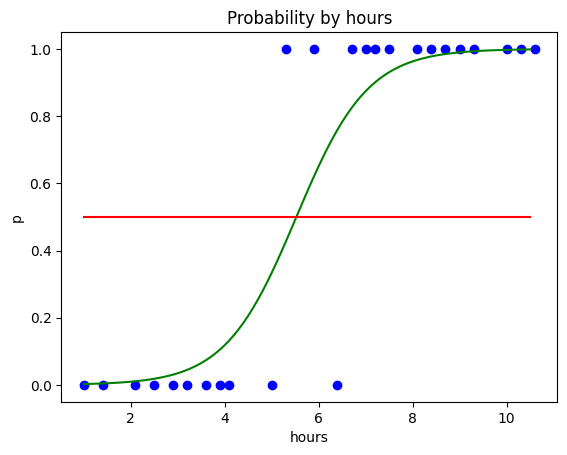

In [25]:
X_range = np.arange(min(X_train), max(X_train), 0.1)
p = 1 / (1 + np.exp(-(classifier.coef_ * X_range + classifier.intercept_)))
p = p.reshape(-1)

plt.scatter(X_train, y_train, color='blue')
plt.plot(X_range, p, color='green')
plt.plot(X_range, np.full(len(X_range), 0.5), color='red')

plt.title("Probability by hours")
plt.xlabel("hours")
plt.ylabel("p")

plt.show()

## 6) 데이터 시각화 (테스트 세트) 코드를 작성하시오.

- 테스트 세트의 실제 값과 예측 결과를 비교할 수 있도록 시각화하시오.

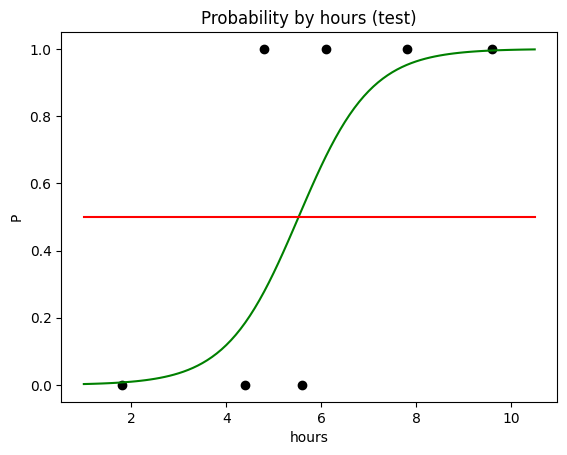

In [26]:
plt.scatter(X_test, y_test, color="black")
plt.plot(X_range, p, color='green')
plt.plot(X_range, np.full(len(X_range), 0.5), color='red')

plt.title('Probability by hours (test)')
plt.xlabel('hours')
plt.ylabel('P')
plt.show()

## 7) 훈련 세트, 테스트 세트에 대해 각각 모델 평가 점수(accuracy)를 구하시오.

In [29]:
classifier.score(X_train, y_train)

0.92

In [30]:
classifier.score(X_test, y_test)

0.7142857142857143

## 8) 주간 학습 시간이 6.5시간일 때 예상되는 합격 여부와 합격 확률을 구하시오. 또한 결과를 한 문장으로 해석하시오.

In [32]:
classifier.predict([[6.5]])

array([1])

In [33]:
classifier.predict_proba([[6.5]])

array([[0.2172902, 0.7827098]])

>> 주간 학습 시간이 6.5시간일 때는 78%의 확률로 합격을 한 것으로 예상할 수 있다.
그러나 이 모델의 성능을 분석해본 결과 테스트 케이스에 대해서의 성능이 훈련 데이터에 비해 낮은 것을 보아 과적합이 된 모델로 예상할 수 있다.